In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

# Caminho dos arquivos .nc
data_dir = "/home/matheus/Documentos/GitHub/LACRIO/Analises/ERA5_dados/dados_era5_03"
nc_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".nc")])

# Estações
stations = [
    {"name": "CDAWX", "lat": -9.46 , "lon": -77.37, "color": "green"},
    {"name": "Cuchillacocha – CuchQ", "lat": -9.41, "lon": -77.35, "color": "blue"},
    {"name": "Llanganuco (LlanQ)", "lat": -9.07, "lon": -77.65, "color": "red"}
]

# Inicializa dicionários de DataFrames: {(station, level): pd.Series()}
temperature_df = {}
humidity_df = {}

# Descobrir níveis de pressão no primeiro arquivo
sample_file = xr.open_dataset(os.path.join(data_dir, nc_files[0]))
pressure_levels = sample_file.pressure_level.values
sample_file.close()

# Inicializa estruturas
for s in stations:
    for level in pressure_levels:
        key = (s["name"], level)
        temperature_df[key] = pd.Series(dtype=float)
        humidity_df[key] = pd.Series(dtype=float)

# Função para extrair variável
def extract_series(ds, var, lat, lon, level):
    return ds[var].sel(pressure_level=level, latitude=lat, longitude=lon, method="nearest").to_series()

# Processa arquivos
for file in nc_files:
    path = os.path.join(data_dir, file)
    ds = xr.open_dataset(path)

    for s in stations:
        lat, lon, name = s["lat"], s["lon"], s["name"]
        
        for level in pressure_levels:
            key = (name, level)
            try:
                temp = extract_series(ds, "t", lat, lon, level)
                q = extract_series(ds, "q", lat, lon, level)

                temperature_df[key] = pd.concat([temperature_df[key], temp])
                humidity_df[key] = pd.concat([humidity_df[key], q])
            except Exception as e:
                print(f"Erro ao extrair {name} nível {level}: {e}")

    ds.close()

# Converter dicionários para DataFrames indexados por tempo
df_temp = pd.DataFrame({k: v for k, v in temperature_df.items()})
df_q = pd.DataFrame({k: v for k, v in humidity_df.items()})

df_temp.index = pd.to_datetime(df_temp.index)
df_q.index = pd.to_datetime(df_q.index)
df_temp.sort_index(inplace=True)
df_q.sort_index(inplace=True)

# Converte temperatura para Celsius
df_temp_celsius = df_temp - 273.15

# --- Geração de gráficos separados por estação e nível ---
for s in stations:
    name = s["name"]
    color = s["color"]
    
    for level in pressure_levels:
        key = (name, level)
        
        # Temperatura
        plt.figure(figsize=(15, 4))
        plt.plot(df_temp_celsius[key], color=color)
        plt.title(f"Temperatura (°C) - Estação: {name} | Nível: {level} hPa")
        plt.ylabel("Temperatura (°C)")
        plt.xlabel("Tempo")
        plt.grid()
        plt.tight_layout()
        plt.show()
        
        # Umidade específica
        plt.figure(figsize=(15, 4))
        plt.plot(df_q[key], color=color)
        plt.title(f"Umidade Específica (kg/kg) - Estação: {name} | Nível: {level} hPa")
        plt.ylabel("Umidade Específica")
        plt.xlabel("Tempo")
        plt.grid()
        plt.tight_layout()
        plt.show()


AttributeError: 'Dataset' object has no attribute 'pressure_level'

Erro ao extrair CDAWX: "No variable named 't2m'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']"
Erro ao extrair Cuchillacocha – CuchQ: "No variable named 't2m'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']"
Erro ao extrair Llanganuco (LlanQ): "No variable named 't2m'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']"
Erro ao extrair CDAWX: "No variable named 't2m'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']"
Erro ao extrair Cuchillacocha – CuchQ: "No variable named 't2m'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']"
Erro ao extrair Llanganuco (LlanQ): "No variable named 't2m'. Variables on the dataset include ['num

/tmp/ipykernel_19688/2349391270.py:37: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  temperature_df[name] = pd.concat([temperature_df[name], temp])


Erro ao extrair CDAWX: "No variable named 't2m'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']"
Erro ao extrair Cuchillacocha – CuchQ: "No variable named 't2m'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']"
Erro ao extrair Llanganuco (LlanQ): "No variable named 't2m'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']"
Erro ao extrair CDAWX: "No variable named 't2m'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']"
Erro ao extrair Cuchillacocha – CuchQ: "No variable named 't2m'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']"
Erro ao extrair Llanganuco (LlanQ): "No variable named 't2m'. Variables on the dataset include ['num

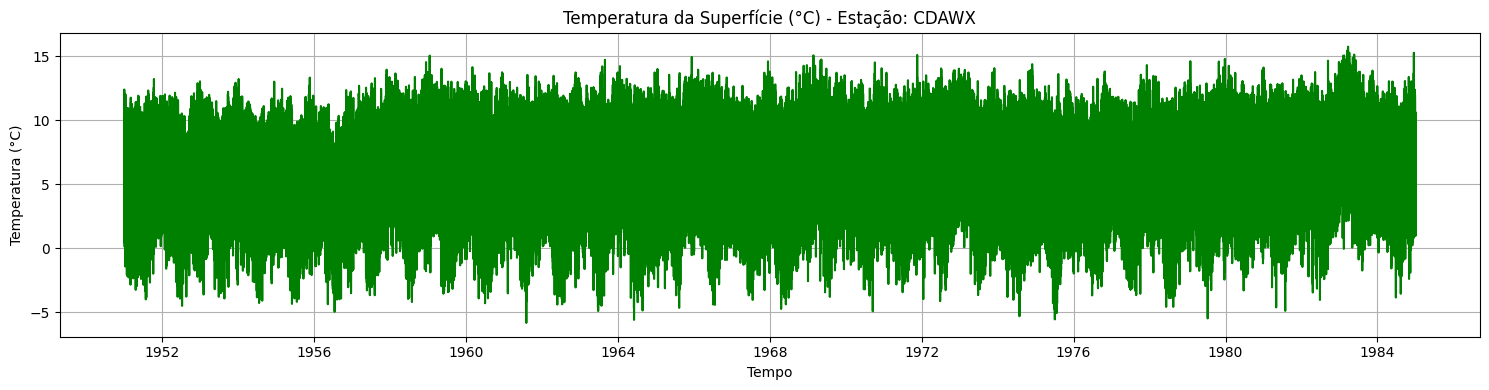

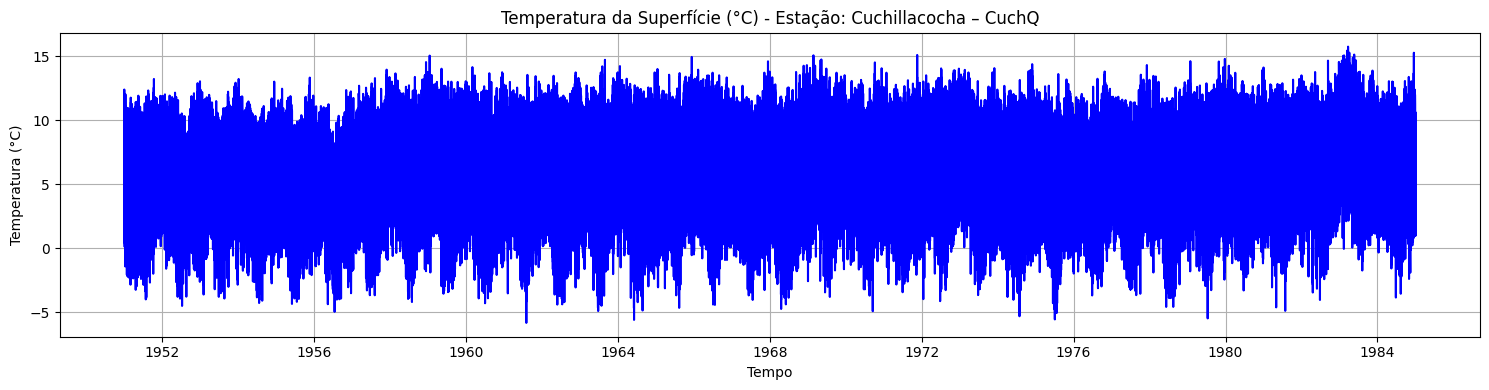

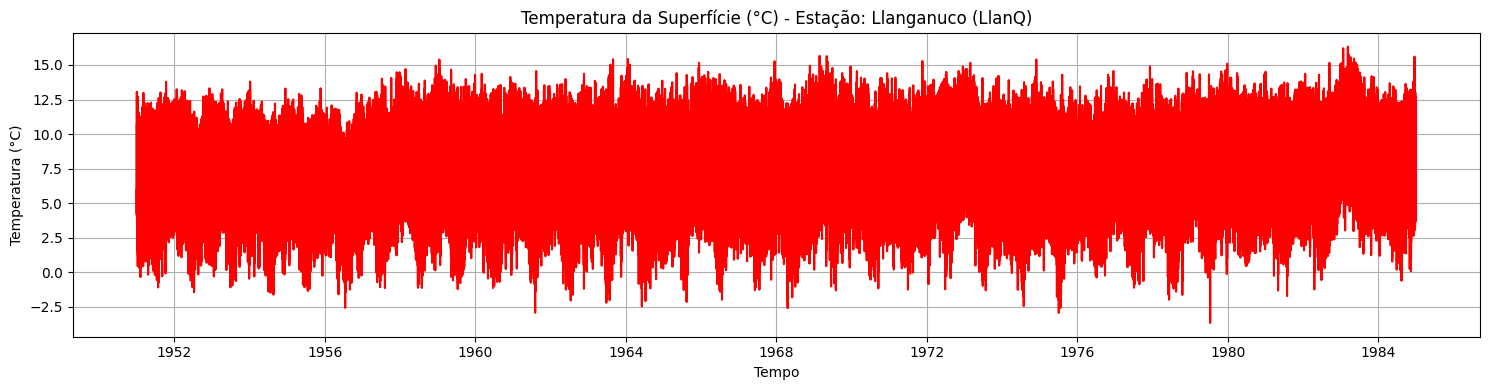

Arquivos encontrados: ['ERA5_1951_ins.nc', 'ERA5_1952_ins.nc', 'ERA5_1953_ins.nc', 'ERA5_1954_ins.nc', 'ERA5_1955_ins.nc', 'ERA5_1956_ins.nc', 'ERA5_1957_ins.nc', 'ERA5_1958_ins.nc', 'ERA5_1959_ins.nc', 'ERA5_1960_ins.nc', 'ERA5_1961_ins.nc', 'ERA5_1962_ins.nc', 'ERA5_1963_ins.nc', 'ERA5_1964_ins.nc', 'ERA5_1965_ins.nc', 'ERA5_1966_ins.nc', 'ERA5_1967_ins.nc', 'ERA5_1968_ins.nc', 'ERA5_1969_ins.nc', 'ERA5_1970_ins.nc', 'ERA5_1971_ins.nc', 'ERA5_1972_ins.nc', 'ERA5_1973_ins.nc', 'ERA5_1974_ins.nc', 'ERA5_1975_ins.nc', 'ERA5_1976_ins.nc', 'ERA5_1977_ins.nc', 'ERA5_1978_ins.nc', 'ERA5_1979_ins.nc', 'ERA5_1980_ins.nc', 'ERA5_1981_ins.nc', 'ERA5_1982_ins.nc', 'ERA5_1983_ins.nc', 'ERA5_1984_ins.nc', 'ERA5_1985_ins.nc']


/tmp/ipykernel_19688/3882906647.py:54: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_temp_celsius_annual = df_temp_celsius.resample('Y').mean()


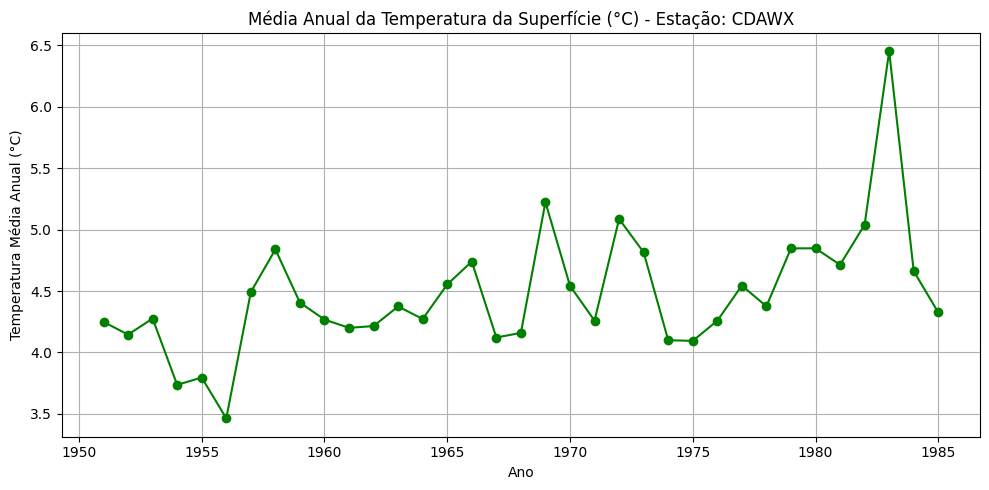

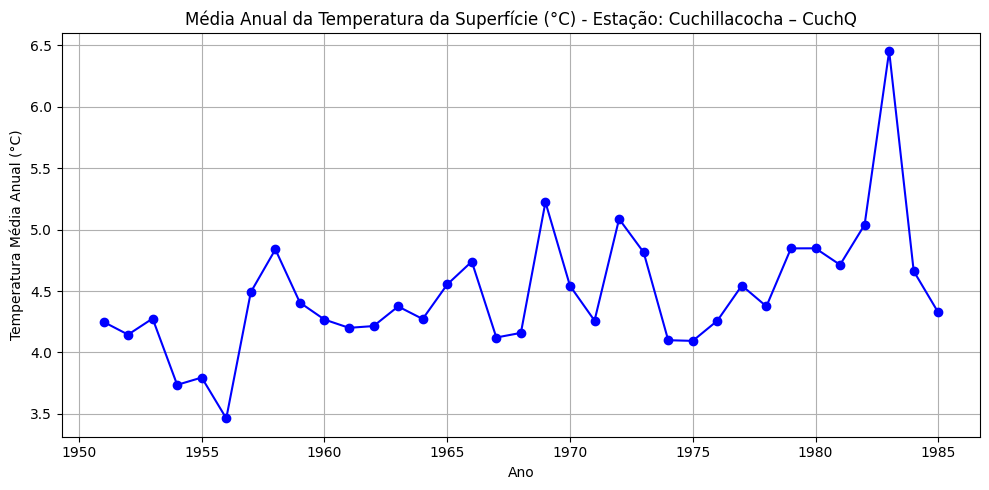

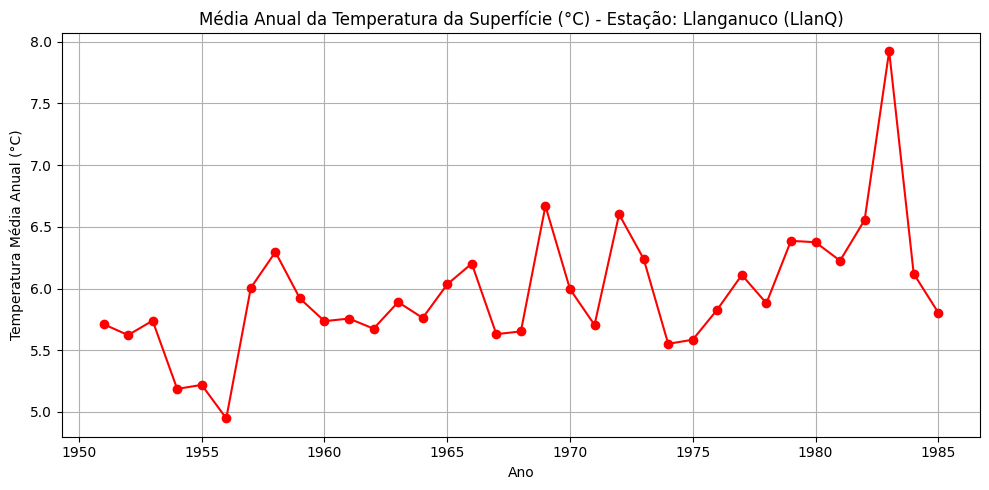

In [5]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

# Caminho dos arquivos .nc
data_dir = "/home/matheus/Documentos/GitHub/LACRIO/Analises/ERA5_dados/dados_era5_03"
nc_files = sorted([f for f in os.listdir(data_dir) if f.endswith("ins.nc")])

# Verifica arquivos encontrados
print(f"Arquivos encontrados: {nc_files}")

# Abre e concatena todos os arquivos com xarray
dataset = xr.open_mfdataset([os.path.join(data_dir, f) for f in nc_files], combine='by_coords')

# Estações
stations = [
    {"name": "CDAWX", "lat": -9.46 , "lon": -77.37, "color": "green"},
    {"name": "Cuchillacocha – CuchQ", "lat": -9.41, "lon": -77.35, "color": "blue"},
    {"name": "Llanganuco (LlanQ)", "lat": -9.07, "lon": -77.65, "color": "red"}
]

# Inicializa dicionário de DataFrames: {station: pd.Series()}
temperature_df = {}

for s in stations:
    temperature_df[s["name"]] = pd.Series(dtype=float)

# Função para extrair temperatura de superfície
def extract_surface_temp(ds, var, lat, lon):
    return ds[var].sel(latitude=lat, longitude=lon, method="nearest").to_series()

# Processa dados concatenados
for s in stations:
    lat, lon, name = s["lat"], s["lon"], s["name"]
    
    try:
        temp = extract_surface_temp(dataset, "t2m", lat, lon)
        temperature_df[name] = temp
    except Exception as e:
        print(f"Erro ao extrair {name}: {e}")

# Converter dicionário para DataFrame indexado por tempo
df_temp = pd.DataFrame({k: v for k, v in temperature_df.items()})

# Ajuste de índice
df_temp.index = pd.to_datetime(df_temp.index)
df_temp.sort_index(inplace=True)

# Converte temperatura para Celsius
df_temp_celsius = df_temp - 273.15

# --- Cálculo da média anual ---
df_temp_celsius_annual = df_temp_celsius.resample('Y').mean()

# --- Geração de gráficos separados por estação (média anual) ---
for s in stations:
    name = s["name"]
    color = s["color"]
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_temp_celsius_annual.index.year, df_temp_celsius_annual[name], marker='o', color=color)
    plt.title(f"Média Anual da Temperatura da Superfície (°C) - Estação: {name}")
    plt.ylabel("Temperatura Média Anual (°C)")
    plt.xlabel("Ano")
    plt.grid()
    plt.tight_layout()
    plt.show()

# Fecha dataset
dataset.close()


Arquivos encontrados: ['ERA5_1951_ins.nc', 'ERA5_1952_ins.nc', 'ERA5_1953_ins.nc', 'ERA5_1954_ins.nc', 'ERA5_1955_ins.nc', 'ERA5_1956_ins.nc', 'ERA5_1957_ins.nc', 'ERA5_1958_ins.nc', 'ERA5_1959_ins.nc', 'ERA5_1960_ins.nc', 'ERA5_1961_ins.nc', 'ERA5_1962_ins.nc', 'ERA5_1963_ins.nc', 'ERA5_1964_ins.nc', 'ERA5_1965_ins.nc', 'ERA5_1966_ins.nc', 'ERA5_1967_ins.nc', 'ERA5_1968_ins.nc', 'ERA5_1969_ins.nc', 'ERA5_1970_ins.nc', 'ERA5_1971_ins.nc', 'ERA5_1972_ins.nc', 'ERA5_1973_ins.nc', 'ERA5_1974_ins.nc', 'ERA5_1975_ins.nc', 'ERA5_1976_ins.nc', 'ERA5_1977_ins.nc', 'ERA5_1978_ins.nc', 'ERA5_1979_ins.nc', 'ERA5_1980_ins.nc', 'ERA5_1981_ins.nc', 'ERA5_1982_ins.nc', 'ERA5_1983_ins.nc', 'ERA5_1984_ins.nc', 'ERA5_1985_ins.nc']


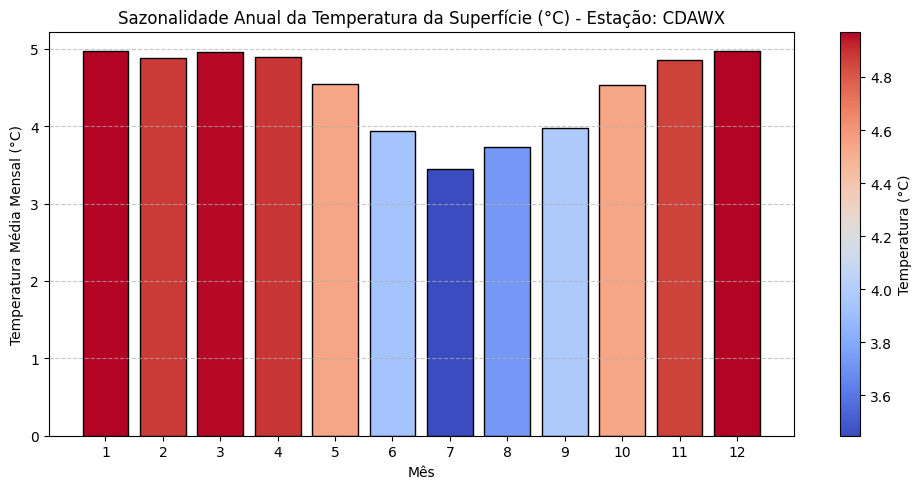

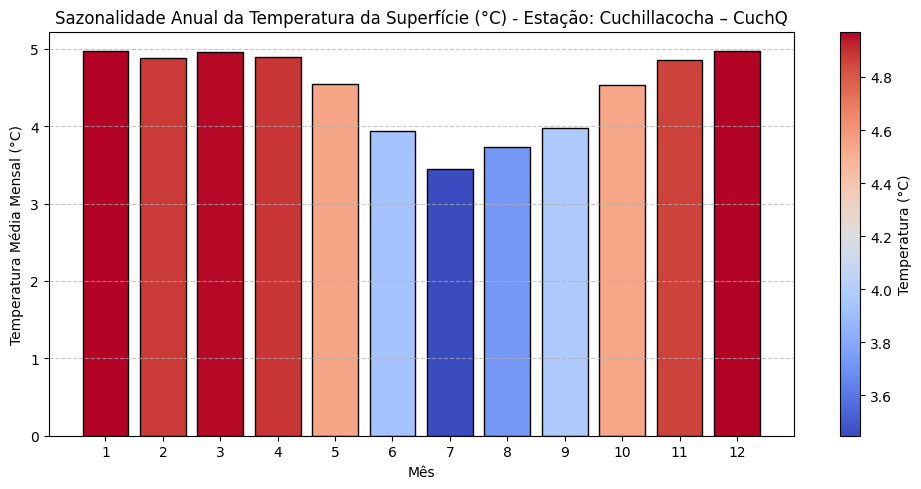

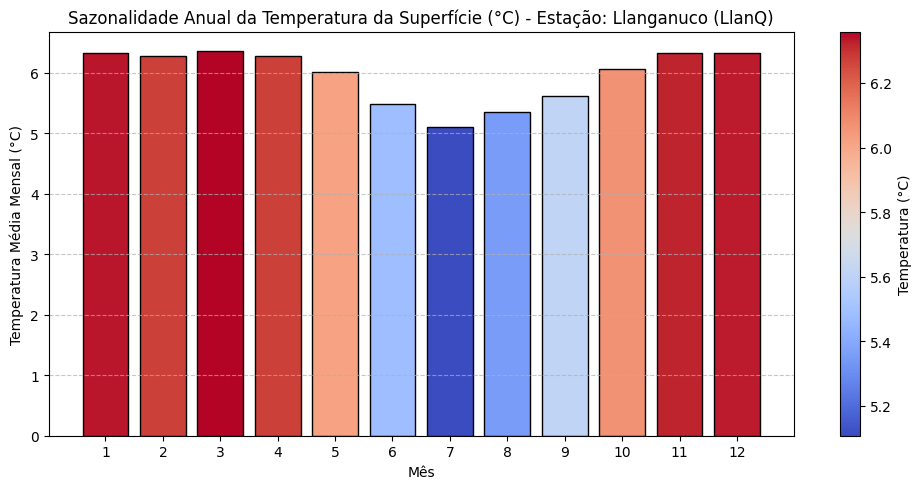

In [9]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Caminho dos arquivos .nc
data_dir = "/home/matheus/Documentos/GitHub/LACRIO/Analises/ERA5_dados/dados_era5_03"
nc_files = sorted([f for f in os.listdir(data_dir) if f.endswith("ins.nc")])

# Verifica arquivos encontrados
print(f"Arquivos encontrados: {nc_files}")

# Abre e concatena todos os arquivos com xarray
dataset = xr.open_mfdataset([os.path.join(data_dir, f) for f in nc_files], combine='by_coords')

# Estações
stations = [
    {"name": "CDAWX", "lat": -9.46 , "lon": -77.37},
    {"name": "Cuchillacocha – CuchQ", "lat": -9.41, "lon": -77.35},
    {"name": "Llanganuco (LlanQ)", "lat": -9.07, "lon": -77.65}
]

# Inicializa dicionário de DataFrames: {station: pd.Series()}
temperature_df = {}

for s in stations:
    temperature_df[s["name"]] = pd.Series(dtype=float)

# Função para extrair temperatura de superfície
def extract_surface_temp(ds, var, lat, lon):
    return ds[var].sel(latitude=lat, longitude=lon, method="nearest").to_series()

# Processa dados concatenados
for s in stations:
    lat, lon, name = s["lat"], s["lon"], s["name"]
    
    try:
        temp = extract_surface_temp(dataset, "t2m", lat, lon)
        temperature_df[name] = temp
    except Exception as e:
        print(f"Erro ao extrair {name}: {e}")

# Converter dicionário para DataFrame indexado por tempo
df_temp = pd.DataFrame({k: v for k, v in temperature_df.items()})

# Ajuste de índice
df_temp.index = pd.to_datetime(df_temp.index)
df_temp.sort_index(inplace=True)

# Converte temperatura para Celsius
df_temp_celsius = df_temp - 273.15

# --- Cálculo da média mensal (sazonalidade) ---
df_temp_celsius['month'] = df_temp_celsius.index.month
df_seasonal = df_temp_celsius.groupby('month').mean()

# --- Geração de gráfico de barras com colorbar para cada estação ---
for s in stations:
    name = s["name"]
    
    # Dados
    months = df_seasonal.index
    values = df_seasonal[name].values

    # Normaliza para colormap
    norm = Normalize(vmin=np.min(values), vmax=np.max(values))
    cmap = plt.get_cmap('coolwarm')
    colors = cmap(norm(values))

    fig, ax = plt.subplots(figsize=(10, 5))
    
    bars = ax.bar(months, values, color=colors, edgecolor='black')

    ax.set_title(f"Sazonalidade Anual da Temperatura da Superfície (°C) - Estação: {name}")
    ax.set_ylabel("Temperatura Média Mensal (°C)")
    ax.set_xlabel("Mês")
    ax.set_xticks(range(1,13))
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # obrigatório, mas vazio
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Temperatura (°C)')

    plt.tight_layout()
    plt.show()

# Fecha dataset
dataset.close()


Arquivos encontrados: ['ERA5_1951_accum.nc', 'ERA5_1952_accum.nc', 'ERA5_1953_accum.nc', 'ERA5_1954_accum.nc', 'ERA5_1955_accum.nc', 'ERA5_1956_accum.nc', 'ERA5_1957_accum.nc', 'ERA5_1958_accum.nc', 'ERA5_1959_accum.nc', 'ERA5_1960_accum.nc', 'ERA5_1961_accum.nc', 'ERA5_1962_accum.nc', 'ERA5_1963_accum.nc', 'ERA5_1964_accum.nc', 'ERA5_1965_accum.nc', 'ERA5_1966_accum.nc', 'ERA5_1967_accum.nc', 'ERA5_1968_accum.nc', 'ERA5_1969_accum.nc', 'ERA5_1970_accum.nc', 'ERA5_1971_accum.nc', 'ERA5_1972_accum.nc', 'ERA5_1973_accum.nc', 'ERA5_1974_accum.nc', 'ERA5_1975_accum.nc', 'ERA5_1976_accum.nc', 'ERA5_1977_accum.nc', 'ERA5_1978_accum.nc', 'ERA5_1979_accum.nc', 'ERA5_1980_accum.nc', 'ERA5_1981_accum.nc', 'ERA5_1982_accum.nc', 'ERA5_1983_accum.nc', 'ERA5_1984_accum.nc', 'ERA5_1985_accum.nc']


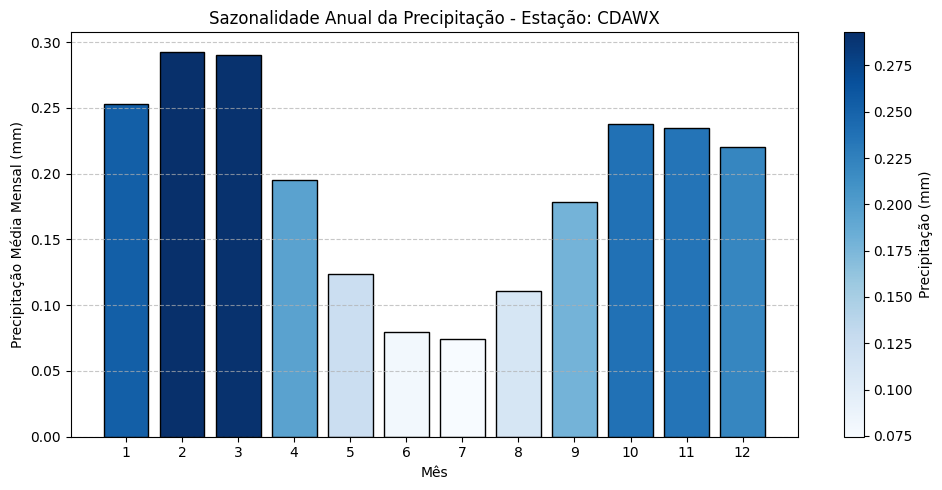

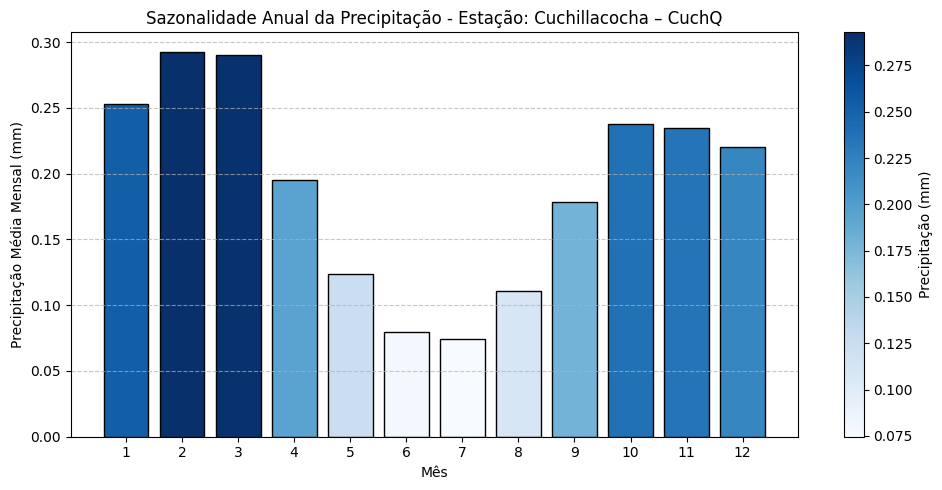

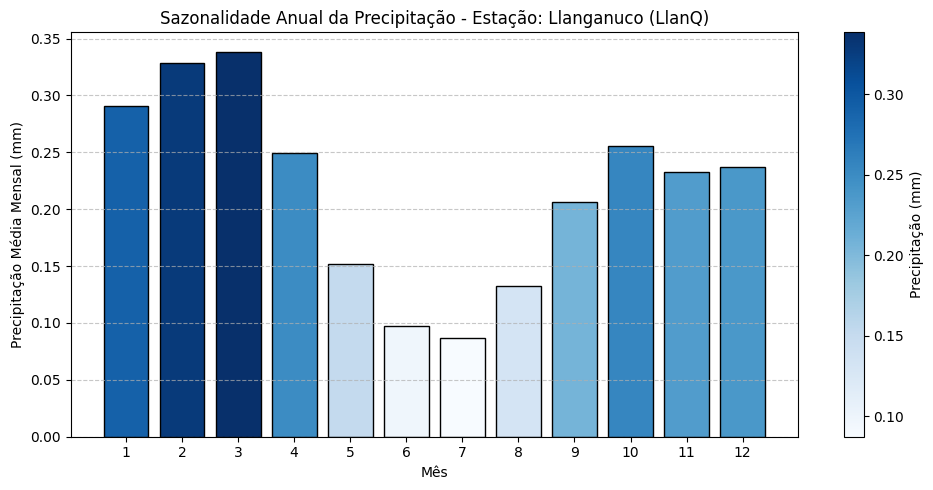

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Caminho dos arquivos .nc
data_dir = "/home/matheus/Documentos/GitHub/LACRIO/Analises/ERA5_dados/dados_era5_03"
nc_files = sorted([f for f in os.listdir(data_dir) if f.endswith("accum.nc")])

print(f"Arquivos encontrados: {nc_files}")

# Abre e concatena todos os arquivos com xarray
dataset = xr.open_mfdataset([os.path.join(data_dir, f) for f in nc_files], combine='by_coords')

# Estações
stations = [
    {"name": "CDAWX", "lat": -9.46 , "lon": -77.37},
    {"name": "Cuchillacocha – CuchQ", "lat": -9.41, "lon": -77.35},
    {"name": "Llanganuco (LlanQ)", "lat": -9.07, "lon": -77.65}
]

# Inicializa dicionário de DataFrames: {station: pd.Series()}
precip_df = {}

for s in stations:
    precip_df[s["name"]] = pd.Series(dtype=float)

# Função para extrair precipitação de superfície
def extract_precip(ds, var, lat, lon):
    return ds[var].sel(latitude=lat, longitude=lon, method="nearest").to_series()

# Processa dados concatenados
for s in stations:
    lat, lon, name = s["lat"], s["lon"], s["name"]
    
    try:
        precip = extract_precip(dataset, "tp", lat, lon)
        precip_df[name] = precip
    except Exception as e:
        print(f"Erro ao extrair {name}: {e}")

# Converter dicionário para DataFrame indexado por tempo
df_precip = pd.DataFrame({k: v for k, v in precip_df.items()})

# Ajuste de índice
df_precip.index = pd.to_datetime(df_precip.index)
df_precip.sort_index(inplace=True)

# Converte precipitação para mm
df_precip_mm = df_precip * 1000  # ERA5 precipitação geralmente em metros

# --- Cálculo da média mensal (sazonalidade) ---
df_precip_mm['month'] = df_precip_mm.index.month
df_seasonal_precip = df_precip_mm.groupby('month').mean()

# --- Geração de gráfico de barras com colorbar para cada estação ---
for s in stations:
    name = s["name"]
    
    months = df_seasonal_precip.index
    values = df_seasonal_precip[name].values

    # Normaliza para colormap
    norm = Normalize(vmin=np.min(values), vmax=np.max(values))
    cmap = plt.get_cmap('Blues')
    colors = cmap(norm(values))

    fig, ax = plt.subplots(figsize=(10, 5))
    
    bars = ax.bar(months, values, color=colors, edgecolor='black')

    ax.set_title(f"Sazonalidade Anual da Precipitação - Estação: {name}")
    ax.set_ylabel("Precipitação Média Mensal (mm)")
    ax.set_xlabel("Mês")
    ax.set_xticks(range(1,13))
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Precipitação (mm)')

    plt.tight_layout()
    plt.show()

# Fecha dataset
dataset.close()


In [3]:
import xarray as xr

# Abrir o arquivo NetCDF
ds = xr.open_dataset('/home/matheus/Documentos/GitHub/LACRIO/Analises/ERA5_dados/dados_era5_03/ERA5_1952_accum.nc')

# Listar todas as variáveis disponíveis
print("Variáveis disponíveis:")
print(list(ds.variables))

# Ou detalhar
print(ds)


Variáveis disponíveis:
['number', 'valid_time', 'latitude', 'longitude', 'expver', 'tp', 'ssrd', 'strd', 'sf']
<xarray.Dataset> Size: 597kB
Dimensions:     (valid_time: 1464, latitude: 6, longitude: 4)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 12kB 1952-01-01 ... 1952-12-31T18...
  * latitude    (latitude) float64 48B -8.65 -8.9 -9.15 -9.4 -9.65 -9.9
  * longitude   (longitude) float64 32B -77.9 -77.65 -77.4 -77.15
    expver      (valid_time) <U4 23kB ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 141kB ...
    ssrd        (valid_time, latitude, longitude) float32 141kB ...
    strd        (valid_time, latitude, longitude) float32 141kB ...
    sf          (valid_time, latitude, longitude) float32 141kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institutio